In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
class CliffWalkingEnv:
    def __init__(self, reward_shape_mode=False):
        self.rows = 4
        self.cols = 12
        self.start_state = (3, 0)
        self.goal_state = (3, 11)
        self.current_state = self.start_state
        
        # Actiuni: 0: UP, 1: RIGHT, 2: DOWN, 3: LEFT
        self.action_deltas = {
            0: (-1, 0),
            1: (0, 1),
            2: (1, 0),
            3: (0, -1)
        }
        # Flag pentru Cerința 4 (Reward Shaping)
        self.reward_shape_mode = reward_shape_mode

    def reset(self):
        """Întoarce agentul la starea inițială."""
        self.current_state = self.start_state
        return self.current_state

    def step(self, action):
        """Execută o acțiune și returnează (next_state, reward, done)."""
        if self.current_state == self.goal_state:
            return self.current_state, 0, True

        delta = self.action_deltas[action]
        next_row = self.current_state[0] + delta[0]
        next_col = self.current_state[1] + delta[1]

        # Verificăm dacă iese de pe grilă -> rămâne pe loc
        if next_row < 0 or next_row >= self.rows or next_col < 0 or next_col >= self.cols:
            next_row, next_col = self.current_state

        next_state = (next_row, next_col)
        done = False

        # Verificăm dacă a căzut în prăpastie (Cliff)
        # Prăpastia este la rândul 3, coloanele de la 1 la 10
        if next_row == 3 and 1 <= next_col <= 10:
            reward = -100
            next_state = self.start_state # Teleport înapoi
            # Observație: Episodul continuă, deci done = False
        elif next_state == self.goal_state:
            reward = 0
            done = True
        else:
            reward = -1

        # --- EXPLICAȚIE CERINȚA 4 (Reward Shaping) ---
        # Pentru a forța SARSA (care e fricos) să meargă pe marginea prăpastiei (la fel ca Q-learning),
        # putem penaliza masiv drumurile "sigure" din partea de sus a grilei.
        if self.reward_shape_mode:
            if not done and next_state != self.start_state:
                # Dacă e pe rândul 0, 1 sau 2, îi dăm o penalizare mai mare decât riscul prăpastiei.
                # Astfel, agentul va prefera să riște căderea decât să piardă puncte ocolind.
                if next_row < 2: 
                    reward = -50 
                elif next_row == 2:
                    reward = -10
        # -----------------------------------------------------

        self.current_state = next_state
        return next_state, reward, done

    def render(self):
        """Afișare ASCII a mediului și a agentului."""
        grid = np.full((self.rows, self.cols), 'o', dtype=str)
        grid[3, 1:11] = 'C' # Cliff
        grid[3, 11] = 'G'   # Goal
        grid[3, 0] = 'S'    # Start
        
        r, c = self.current_state
        grid[r, c] = 'X'    # Agent
        
        print("\n".join(" ".join(row) for row in grid))
        print("-" * 25)

# ==========================================
# FUNCȚII UTILE PENTRU ALGORITMI
# ==========================================
def get_action(Q, state, epsilon):
    """Alege o acțiune folosind politica epsilon-greedy."""
    if np.random.rand() < epsilon:
        return np.random.randint(4) # Explorare
    else:
        # Exploatare: alegem acțiunea cu valoarea Q maximă
        # Folosim random.choice printre maxime pentru a sparge egalitățile (ex: la inițializare)
        q_values = Q[state[0], state[1], :]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]
        return np.random.choice(best_actions)

def visualize_policy(Q, title):
    """Afișează politica greedy învățată (săgeți)."""
    arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    grid = np.full((4, 12), ' ', dtype=str)
    
    for r in range(4):
        for c in range(12):
            if r == 3 and 1 <= c <= 10:
                grid[r, c] = 'C'
            elif r == 3 and c == 11:
                grid[r, c] = 'G'
            else:
                best_action = np.argmax(Q[r, c, :])
                grid[r, c] = arrows[best_action]
                
    print(f"\nPolitica pentru: {title}")
    print("\n".join(" ".join(row) for row in grid))

# ==========================================
# 2. IMPLEMENTAREA Q-LEARNING ȘI SARSA
# ==========================================
def q_learning(env, alpha=0.1, gamma=1.0, epsilon=0.1, episodes=500):
    """Q-learning (Off-policy TD Control)"""
    Q = np.zeros((env.rows, env.cols, 4))
    rewards_per_episode = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        
        while not done:
            action = get_action(Q, state, epsilon)
            next_state, reward, done = env.step(action)
            
            # UPDATE RULE Q-LEARNING: Ținta folosește acțiunea OPTIMĂ din next_state (max_a')
            # Indiferent ce va alege agentul efectiv la pasul următor.
            best_next_action = np.argmax(Q[next_state[0], next_state[1], :])
            td_target = reward + gamma * Q[next_state[0], next_state[1], best_next_action]
            td_error = td_target - Q[state[0], state[1], action]
            
            Q[state[0], state[1], action] += alpha * td_error
            
            total_reward += reward
            state = next_state
            
        rewards_per_episode.append(total_reward)
        
    return Q, rewards_per_episode

def sarsa(env, alpha=0.1, gamma=1.0, epsilon=0.1, episodes=500, epsilon_decay=1.0):
    """SARSA (On-policy TD Control)"""
    Q = np.zeros((env.rows, env.cols, 4))
    rewards_per_episode = []
    
    current_epsilon = epsilon

    for ep in range(episodes):
        state = env.reset()
        action = get_action(Q, state, current_epsilon) # Acțiunea inițială
        total_reward = 0
        done = False
        
        while not done:
            next_state, reward, done = env.step(action)
            # Aici SARSA alege DEJA următoarea acțiune pe baza politicii curente (cu tot cu explorare)
            next_action = get_action(Q, next_state, current_epsilon)
            
            # UPDATE RULE SARSA: Ținta folosește acțiunea EFECTIV ALEASĂ pentru next_state
            if done:
                td_target = reward 
            else:
                td_target = reward + gamma * Q[next_state[0], next_state[1], next_action]
                
            td_error = td_target - Q[state[0], state[1], action]
            Q[state[0], state[1], action] += alpha * td_error
            
            total_reward += reward
            state = next_state
            action = next_action # Mutăm acțiunea pentru bucla următoare
            
        rewards_per_episode.append(total_reward)
        
        # Pentru Cerința 5 (Epsilon Scheduling)
        current_epsilon *= epsilon_decay
        
    return Q, rewards_per_episode

In [1]:
def test_agent(env, Q, name="Agent"):
    """
    Rulează un episod complet folosind politica greedy (cea mai bună acțiune) 
    și afișează vizual fiecare pas.
    """
    print(f"\n=== TESTARE POLITICĂ: {name} ===")
    state = env.reset()
    done = False
    steps = 0
    total_reward = 0

    # Afișăm starea inițială
    env.render()

    while not done:
        # Alegem acțiunea OPTIMĂ (fără explorare)
        action = np.argmax(Q[state[0], state[1], :])
        
        state, reward, done = env.step(action)
        total_reward += reward
        steps += 1
        
        # Randăm mediul după fiecare pas
        print(f"Pasul: {steps} | Acțiune: {action} | Recompensă: {reward}")
        env.render()

        # Siguranță pentru a nu intra în bucle infinite dacă politica e greșită
        if steps > 50:
            print("Test oprit: Agentul a depășit 50 de pași.")
            break

    print(f"Test finalizat! Pași totali: {steps} | Recompensă totală: {total_reward}")

In [14]:
def main():
    np.random.seed(42)
    
    env = CliffWalkingEnv()
    
    print("--- Rulare Experiența Centrală (Cerința 3) ---")
    Q_qlearn, rews_qlearn = q_learning(env, alpha=0.1, gamma=1.0, epsilon=0.1, episodes=500)
    Q_sarsa, rews_sarsa = sarsa(env, alpha=0.1, gamma=1.0, epsilon=0.1, episodes=500)
    
    visualize_policy(Q_qlearn, "Q-Learning")
    visualize_policy(Q_sarsa, "SARSA")
    
    # Grafic (Cerința 3)
    window = 10
    qlearn_smoothed = np.convolve(rews_qlearn, np.ones(window)/window, mode='valid')
    sarsa_smoothed = np.convolve(rews_sarsa, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(10, 5))
    plt.plot(qlearn_smoothed, label='Q-Learning (Off-policy)', color='red')
    plt.plot(sarsa_smoothed, label='SARSA (On-policy)', color='blue')
    plt.title('Suma recompenselor per episod (Fereastră mobilă: 10)')
    plt.xlabel('Episod')
    plt.ylabel('Recompensă')
    plt.legend()
    plt.grid()
    plt.show()

    """
    ================================================================================
    RĂSPUNSURI CERINȚA 3
    ================================================================================
    (a) 
    - Q-learning învață drumul CEL MAI SCURT (chiar pe marginea prăpastiei).
    - SARSA obține o sumă cumulată MAI MARE în timpul antrenamentului (linia albastră pe grafic 
      este deasupra liniei roșii), deoarece cade mult mai rar în prăpastie.

    (b) De ce converg diferit?
    Totul se reduce la cum construiesc "Ținta" (Target-ul) în ecuația de update.
    - Q-Learning este OFF-POLICY: Evaluează starea următoare folosind `max Q(s', a')`. El presupune 
      în mod "optimist" că la pasul următor va lua decizia perfectă. Ignoră complet faptul că, fiindcă 
      folosește eps-greedy, la pasul următor s-ar putea să exploreze aleator și să cadă în prăpastie.
    - SARSA este ON-POLICY: Evaluează starea următoare folosind acțiunea eșantionată EFECTIV `Q(s', a')`, 
      inclusiv explorarea (eps-greedy). El "știe" că uneori face pași la întâmplare. Dacă merge pe marginea 
      prăpastiei, o explorare aleatoare îl aruncă direct jos. Prin urmare, valoarea stărilor de pe margine 
      devine foarte mică (negativă) din cauza căderilor dese, așa că învață să meargă mai sus, pe un drum "sigur".

    (c) Contradicția aparentă:
    Nu există o contradicție între a găsi drumul optim (Q-learning) și a avea un scor mai prost la antrenament.
    Q-learning știe politica optimă teoretică, dar pentru că ESTE FORȚAT să exploreze (epsilon=0.1) în timpul 
    antrenamentului, el cade constant din cauză că alege drumul lipit de prăpastie. SARSA preferă să ocolească, 
    deci ia penalizări de -1 pe un drum mai lung, dar evită penalizările de -100 ale prăpastiei generate de 
    propriile lui mișcări exploratorii.
    ================================================================================
    """

    print("\n--- Rulare Provocare Reward Shaping (Cerința 4) ---")
    env_shaped = CliffWalkingEnv(reward_shape_mode=True)
    Q_sarsa_shaped, _ = sarsa(env_shaped, alpha=0.1, gamma=1.0, epsilon=0.1, episodes=500)
    visualize_policy(Q_sarsa_shaped, "SARSA cu Reward Shaping (Forțat pe margine)")
    
    """
    RĂSPUNS CERINȚA 4:
    Pentru ca ambii algoritmi să conveargă la același drum (cel scurt, de pe margine), am modificat
    funcția de recompensă în `CliffWalkingEnv.step()`. Dacă agentul încearcă să ocolească prăpastia
    prin partea de sus (rândurile 0, 1, 2), primește o penalizare enormă (ex: -50 per pas), mult mai gravă 
    decât riscul de a cădea în prăpastie ocazional.
    Justificare mecanică: SARSA calculează valoarea așteptată. Dacă ocolul îi aduce -50 * 12 pași = -600, 
    iar drumul pe margine îi aduce -12 pași optimi + riscul de 10% de a cădea (-100), media matematică 
    devine mai favorabilă pentru marginea prăpastiei. SARSA este practic "împins" pe margine de frica 
    unei penalizări și mai mari sus.
    """

    print("\n--- Rulare Provocare Epsilon-Scheduling (Cerința 5) ---")
    # Setăm decay astfel încât după ~400 de episoade epsilon să fie aproape 0
    # 0.1 * (0.99)^400 ~= 0.001
    Q_sarsa_decay, _ = sarsa(env, alpha=0.1, gamma=1.0, epsilon=0.1, episodes=500, epsilon_decay=0.99)
    visualize_policy(Q_sarsa_decay, "SARSA cu Epsilon Decay (converge la drumul scurt)")
    
    """
    RĂSPUNS CERINȚA 5:
    Am introdus parametrul `epsilon_decay = 0.99` care se înmulțește cu epsilon la finalul fiecărui episod.
    Argumentație: 
    Ținta SARSA este: Target = R + gamma * Q(S', A'). A' este extras din politica eps-greedy.
    Când epsilon tinde la 0 (explorarea se oprește), politica eps-greedy devine o politică pur greedy.
    În acel moment, A' ales de SARSA va fi întotdeauna actiunea optimă: A' = argmax Q(S', a).
    Dacă înlocuim asta în formulă, ținta devine: Target = R + gamma * Q(S', argmax Q(S', a)) 
    Adică fix R + gamma * max Q(S', a). 
    Formula SARSA colapsează exact în formula Q-learning! De aceea politicile devin identice.
    """

    """
    ================================================================================
    RĂSPUNSURI CERINȚA 6 (Reflecție teoretică)
    ================================================================================
    1. Ce se întâmplă dacă setați epsilon = 0 de la început?
       - Nici Q-learning, nici SARSA nu ar explora deloc mediul. Ambii ar face acțiuni bazate pe 
         inițializarea de 0 a tabelei (probabil s-ar bloca într-o buclă stânga-dreapta sau nu ar găsi 
         niciodată Goal-ul). Fără explorare, nu există învățare în medii necunoscute.

    2. Dacă gamma < 1 (ex. gamma = 0.9), cum se schimbă preferința?
       - Un gamma mai mic face agentul mai "miop", adică dă o importanță mai mică penalizărilor aflate 
         mult în viitor și favorizează recompensele/penalizările imediate. Drumul ocolit va părea mai puțin 
         rău de departe, dar pe măsură ce agentul face pași, penalizările constante de -1 se adună repede. 
         Totuși, Q-learning își menține preferința pentru drumul scurt (optimizând pașii rămași), în timp 
         ce SARSA ar putea alege un drum intermediar.

    3. Exemplu din lumea reală (preferință SARSA vs Q-Learning):
       - Robot autonom care livrează medicamente într-un spital. Dacă antrenezi robotul în lumea reală,
         vei prefera SARSA. Q-learning (fiind off-policy) ar încerca să găsească cea mai scurtă rută 
         (ex: milimetric pe lângă scări), ceea ce în timpul explorării ar duce la căderea și distrugerea 
         robotului scump. SARSA este conștient de erorile sale de explorare și va alege calea pe mijlocul
         holului, un comportament mult mai sigur pentru un agent fizic.
    ================================================================================
    """

    test_agent(env, Q_qlearn, name="Q-Learning (Optimistul)")
    test_agent(env, Q_sarsa, name="SARSA (Prudentul)")

--- Rulare Experiența Centrală (Cerința 3) ---

Politica pentru: Q-Learning
↑ → ↓ → ↑ → → → → ↑ → ↓
→ ↓ → → ↓ → → ↓ → → ↓ ↓
→ → → → → → → → → → → ↓
↑ C C C C C C C C C C G

Politica pentru: SARSA
↓ → ↑ → → → → → → ↓ → →
→ → → → → → → → → → → ↓
↑ ↑ ← ↑ ← → ← ↑ ↑ ↑ → ↓
↑ C C C C C C C C C C G


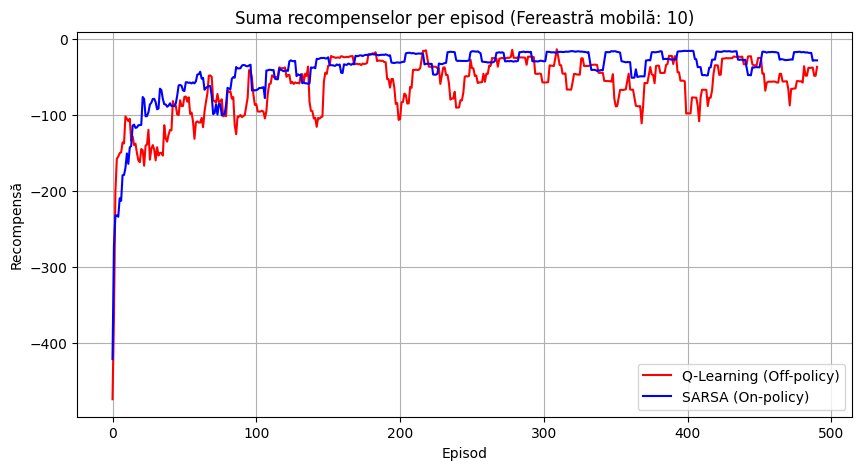


--- Rulare Provocare Reward Shaping (Cerința 4) ---

Politica pentru: SARSA cu Reward Shaping (Forțat pe margine)
↓ ↑ ↓ → ← ↑ ↓ ↓ → → ↓ ←
↓ ↑ ↓ ← ↓ ↓ ↓ ↓ → ↓ ↓ ↓
→ → → → → → → → → → → ↓
↑ C C C C C C C C C C G

--- Rulare Provocare Epsilon-Scheduling (Cerința 5) ---

Politica pentru: SARSA cu Epsilon Decay (converge la drumul scurt)
← → ← → → → → → ↓ → ↓ ↓
↑ → → → → → → → → → → ↓
→ → → → → → → → → → → ↓
↑ C C C C C C C C C C G

=== TESTARE POLITICĂ: Q-Learning (Optimistul) ===
o o o o o o o o o o o o
o o o o o o o o o o o o
o o o o o o o o o o o o
X C C C C C C C C C C G
-------------------------
Pasul: 1 | Acțiune: 0 | Recompensă: -1
o o o o o o o o o o o o
o o o o o o o o o o o o
X o o o o o o o o o o o
S C C C C C C C C C C G
-------------------------
Pasul: 2 | Acțiune: 1 | Recompensă: -1
o o o o o o o o o o o o
o o o o o o o o o o o o
o X o o o o o o o o o o
S C C C C C C C C C C G
-------------------------
Pasul: 3 | Acțiune: 1 | Recompensă: -1
o o o o o o o o o o o o
o o o o o 

In [15]:
main()